In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/Sepsis Prediction Dataset.csv')

print("First 5 rows:")
display(df.head())

print(f"\nShape of data: {df.shape}")


First 5 rows:


,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0,17072
1,1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,0,17072
2,2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0,17072
3,3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,4,0,17072
4,4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,...,NaN,330.0,68.54,0,NaN,NaN,-0.02,5,0,17072



Shape of data: (1552210, 44)


In [ ]:

print("\nData info:")
df.info()

print("\nFirst 10 column names:")
print(df.columns[:10].tolist())

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns
print(f"\nNumeric columns: {len(num_cols)} | Categorical columns: {len(cat_cols)}")



Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126166 entries, 0 to 126165
Data columns (total 44 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        126166 non-null  int64  
 1   Hour              126166 non-null  int64  
 2   HR                116294 non-null  float64
 3   O2Sat             111025 non-null  float64
 4   Temp              42782 non-null   float64
 5   SBP               106626 non-null  float64
 6   MAP               113185 non-null  float64
 7   DBP               66578 non-null   float64
 8   Resp              113447 non-null  float64
 9   EtCO2             0 non-null       float64
 10  BaseExcess        12725 non-null   float64
 11  HCO3              10092 non-null   float64
 12  FiO2              17597 non-null   float64
 13  pH                14047 non-null   float64
 14  PaCO2             10700 non-null   float64
 15  SaO2              5932 non-null    float64
 16  AST     


Top correlations with SepsisLabel:


,SepsisLabel
SepsisLabel,1.000000
ICULOS,0.165287
Unnamed: 0,0.165248
Hour,0.165248
Bilirubin_direct,0.149497
Bilirubin_total,0.104103
Resp,0.063772
Alkalinephos,0.059227
Fibrinogen,0.052565
Unit1,0.049709


,SepsisLabel
Unit2,-0.049709
TroponinI,-0.043803
HospAdmTime,-0.026255
Hgb,-0.026063
Chloride,-0.024566
Hct,-0.019229
HCO3,-0.016144
MAP,-0.014452
Potassium,-0.014226
Platelets,-0.007053


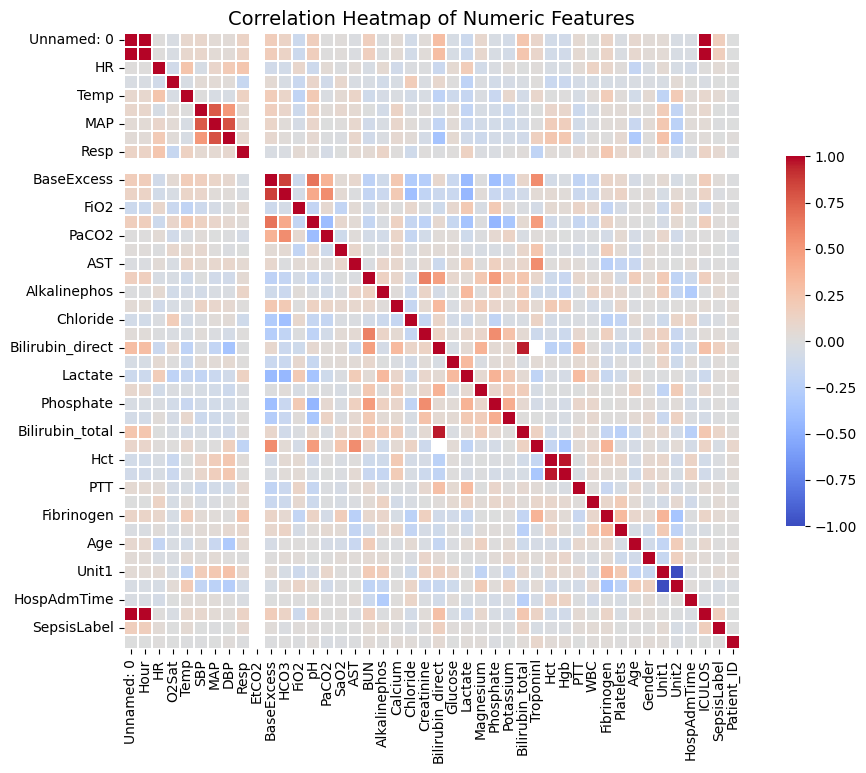

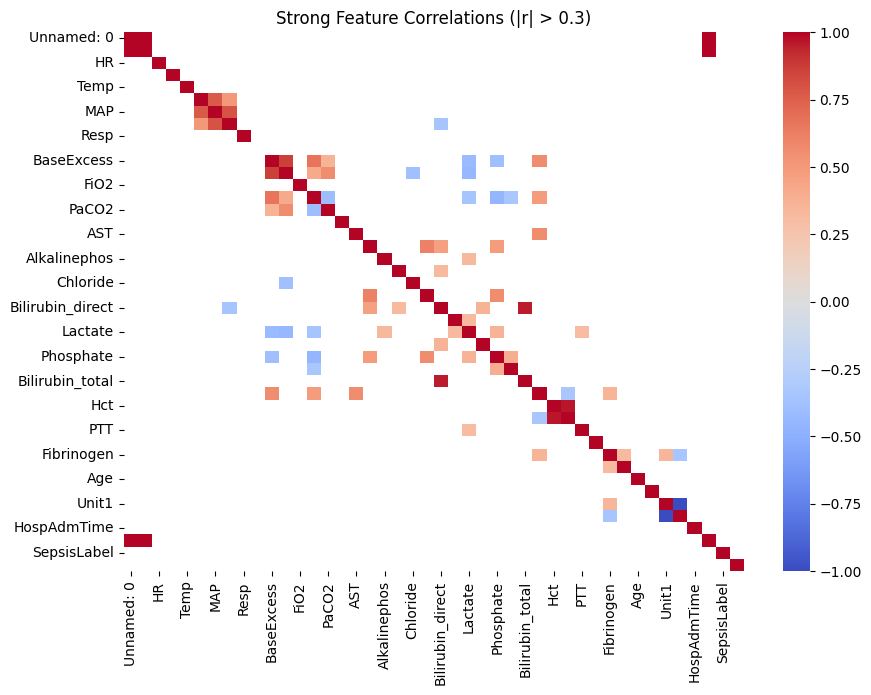

In [ ]:

num_df = df.select_dtypes(include=np.number)

corr_matrix = num_df.corr()

if 'SepsisLabel' in corr_matrix.columns:
    print("\nTop correlations with SepsisLabel:")
    display(corr_matrix['SepsisLabel'].sort_values(ascending=False).head(10))
    display(corr_matrix['SepsisLabel'].sort_values().head(10))

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    square=True,
    cbar_kws={'shrink': 0.6},
    linewidths=0.3
)
plt.title('Correlation Heatmap of Numeric Features', fontsize=14)
plt.show()

strong_corr = corr_matrix[(corr_matrix > 0.3) | (corr_matrix < -0.3)]
plt.figure(figsize=(10, 7))
sns.heatmap(strong_corr, cmap='coolwarm', center=0, annot=False)
plt.title('Strong Feature Correlations (|r| > 0.3)')
plt.show()


In [ ]:
df_clean = df.copy()

df_clean = df_clean.drop_duplicates()

df_clean = df_clean.sort_values(by=['Patient_ID', 'Hour']).reset_index(drop=True)



In [ ]:
missing_percent = df_clean.isnull().mean() * 100
cols_to_drop = missing_percent[missing_percent > 95].index
print(f"Dropping {len(cols_to_drop)} mostly-missing columns.")
df_clean = df_clean.drop(columns=cols_to_drop)

df_clean = df_clean.groupby('Patient_ID').apply(lambda group: group.ffill().bfill()).reset_index(drop=True)

df_clean = df_clean.fillna(df_clean.median(numeric_only=True))


Dropping 12 mostly-missing columns.


/tmp/ipython-input-1736711766.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_clean = df_clean.groupby('Patient_ID').apply(lambda group: group.ffill().bfill()).reset_index(drop=True)


In [ ]:

num_cols = df_clean.select_dtypes(include=np.number).columns

for col in num_cols:
    Q1 = df_clean[col].quantile(0.01)
    Q3 = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(Q1, Q3)


In [ ]:
print("Shape of data:",df_clean.shape)

Shape of data: (126165, 32)


In [ ]:
!pip install Optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 14.2 MB/s eta 0:00:00


In [ ]:
# @title Try 2

import os
import random
import warnings
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit, StratifiedKFold, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, average_precision_score)
from sklearn.base import clone

import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import optuna

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

csv_path = "/content/Sepsis Prediction Dataset.csv"
TARGET = 'SepsisLabel'
GROUP = 'Patient_ID'

META_SEQ = 3

BASE_N_FOLDS_OOF = 3
META_N_FOLDS = 3
OPTUNA_TRIALS = 4
OPTUNA_EPOCHS_CAP = 8
RF_GRID = {'clf__n_estimators': [15], 'clf__max_depth': [6]}
XGB_GRID = {'clf__n_estimators': [15], 'clf__max_depth': [3], 'clf__learning_rate': [0.1]}
LR_GRID = {'clf__C': [0.1]}

df = pd.read_csv(csv_path)

df = df.drop_duplicates()
df = df.sort_values(by=['Patient_ID', 'Hour']).reset_index(drop=True)

missing_percent = df.isnull().mean() * 100
cols_to_drop = missing_percent[missing_percent > 95].index.tolist()
if len(cols_to_drop) > 0:
    print(f"Dropping {len(cols_to_drop)} columns with >95% missing.")
    df = df.drop(columns=cols_to_drop)

df = df.groupby('Patient_ID').apply(lambda g: g.ffill().bfill()).reset_index(drop=True)
df = df.fillna(df.median(numeric_only=True))

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    if col in ['Patient_ID', 'Hour', TARGET]:
        continue
    q1 = df[col].quantile(0.01)
    q3 = df[col].quantile(0.99)
    df[col] = df[col].clip(q1, q3)

print("Preprocessing done. Shape:", df.shape)

drop_cols = [GROUP, TARGET]
feature_cols = [c for c in df.columns if c not in drop_cols]
feature_cols = [c for c in feature_cols if df[c].dtype in [np.float64, np.float32, np.int64, np.int32]]

X = df[feature_cols].copy()
y = df[TARGET].astype(int).values
groups = df[GROUP].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train_df, X_test_df = X.iloc[train_idx].reset_index(drop=True), X.iloc[test_idx].reset_index(drop=True)
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx]
groups_test = groups[test_idx]

print("Train patients:", len(np.unique(groups_train)), "Test patients:", len(np.unique(groups_test)))
print("Train shape:", X_train_df.shape, "Test shape:", X_test_df.shape)
print("Positive rate (train):", y_train.mean(), " (test):", y_test.mean())

imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_train = imputer.fit_transform(X_train_df)
X_test = imputer.transform(X_test_df)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

def evaluate_binary(y_true, y_pred_proba, threshold=0.5):
    if y_pred_proba.ndim == 2 and y_pred_proba.shape[1] == 2:
        pos_prob = y_pred_proba[:, 1]
    else:
        pos_prob = y_pred_proba.ravel()
    y_pred = (pos_prob >= threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    try:
        roc = roc_auc_score(y_true, pos_prob)
    except:
        roc = np.nan
    try:
        pr = average_precision_score(y_true, pos_prob)
    except:
        pr = np.nan
    return [acc, f1, prec, rec, roc, pr]

from sklearn.pipeline import Pipeline as SKPipeline

base_models = {
    'RandomForest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=4),
    'LogisticRegression': LogisticRegression(max_iter=2000, random_state=42)
}

param_grids_pipe = {
    'RandomForest': RF_GRID,
    'XGBoost': XGB_GRID,
    'LogisticRegression': LR_GRID
}

skf = StratifiedKFold(n_splits=BASE_N_FOLDS_OOF, shuffle=True, random_state=42)

oof_preds_base = []
test_preds_base = []
base_results = []

for name, clf in base_models.items():
    print(f"\nTraining base model: {name}")

    pipe = ImbPipeline([('smote', SMOTE(random_state=42)), ('clf', clf)])
    grid = GridSearchCV(pipe, param_grids_pipe[name], cv=3, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)
    print(" Best params (pipeline):", grid.best_params_)

    best_pipe = grid.best_estimator_

    test_pred_proba = best_pipe.predict_proba(X_test)
    oof = np.zeros((X_train.shape[0], 2))
    for tr_idx, val_idx in skf.split(X_train, y_train):
        Xtr, Xval = X_train[tr_idx], X_train[val_idx]
        ytr, yval = y_train[tr_idx], y_train[val_idx]
        sm = SMOTE(sampling_strategy=0.15, random_state=42)
        Xtr_res, ytr_res = sm.fit_resample(Xtr, ytr)
        best_params = {k.replace('clf__', ''): v for k, v in grid.best_params_.items() if k.startswith('clf__')}
        model = clone(clf).set_params(**best_params)
        model.fit(Xtr_res, ytr_res)
        oof[val_idx] = model.predict_proba(Xval)

    oof_preds_base.append(oof)
    test_preds_base.append(test_pred_proba)

    train_metrics = evaluate_binary(y_train, oof)
    test_metrics = evaluate_binary(y_test, test_pred_proba)
    base_results.append({
        'Model': name,
        'Train Acc': train_metrics[0], 'Train F1': train_metrics[1], 'Train Prec': train_metrics[2],
        'Train Rec': train_metrics[3], 'Train ROC': train_metrics[4], 'Train PR': train_metrics[5],
        'Test Acc': test_metrics[0], 'Test F1': test_metrics[1], 'Test Prec': test_metrics[2],
        'Test Rec': test_metrics[3], 'Test ROC': test_metrics[4], 'Test PR': test_metrics[5],
    })
    print(f"{name} metrics (Train OOF): F1={train_metrics[1]:.4f}, ROC-AUC={train_metrics[4]:.4f} | (Test) F1={test_metrics[1]:.4f}, ROC-AUC={test_metrics[4]:.4f}")

X_meta_train = np.hstack(oof_preds_base)
X_meta_test = np.hstack(test_preds_base)
print("\nMeta train shape:", X_meta_train.shape, "Meta test shape:", X_meta_test.shape)

def build_meta_sequences(base_probs, groups_arr, meta_seq_len):
    seqs = []
    idx_map = {}
    for idx, pid in enumerate(groups_arr):
        idx_map.setdefault(pid, []).append(idx)
    for pid, idx_list in idx_map.items():
        for pos, idx in enumerate(idx_list):
            start_pos = max(0, pos - (meta_seq_len - 1))
            seq_indices = idx_list[start_pos:pos+1]
            seq_mat = base_probs[seq_indices]
            if seq_mat.shape[0] < meta_seq_len:
                pad = np.zeros((meta_seq_len - seq_mat.shape[0], base_probs.shape[1]))
                seq_mat = np.vstack([pad, seq_mat])
            seqs.append(seq_mat)
    return np.array(seqs)

X_meta_train_seq = build_meta_sequences(X_meta_train, groups_train, META_SEQ)
X_meta_test_seq = build_meta_sequences(X_meta_test, groups_test, META_SEQ)
print("Meta sequence shapes:", X_meta_train_seq.shape, X_meta_test_seq.shape)

num_classes = 2
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)


def build_label_sequence(labels, groups_arr, meta_seq_len):
    lab_seq = []
    idx_map = {}
    for idx, pid in enumerate(groups_arr):
        idx_map.setdefault(pid, []).append(idx)
    for pid, idx_list in idx_map.items():
        for pos, idx in enumerate(idx_list):
            lab_seq.append(labels[idx])
    return np.array(lab_seq)

y_meta_train = build_label_sequence(y_train, groups_train, META_SEQ)
y_meta_test = build_label_sequence(y_test, groups_test, META_SEQ)

assert X_meta_train_seq.shape[0] == y_meta_train.shape[0]
assert X_meta_test_seq.shape[0] == y_meta_test.shape[0]

def create_meta_model(params, model_type, input_shape, num_classes=2):
    units = params.get('units', 32)
    dropout = params.get('dropout', 0.2)
    lr = params.get('lr', 1e-3)
    model = Sequential()
    model.add(Input(shape=input_shape))
    if model_type == 'LSTM':
        model.add(LSTM(units))
    else:
        model.add(GRU(units))
    model.add(Dropout(dropout))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(optimizer=Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def run_meta_model_seq(model_type, X_tr_seq, y_tr_labels, X_te_seq, y_te_labels, n_folds=META_N_FOLDS, optuna_trials=OPTUNA_TRIALS):
    skf_local = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    y_flat = y_tr_labels

    def objective(trial):
        params = {
            'units': trial.suggest_int('units', 16, 64),
            'dropout': trial.suggest_float('dropout', 0.1, 0.5),
            'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'epochs': trial.suggest_int('epochs', 2, min(6, OPTUNA_EPOCHS_CAP)),
            'batch_size': trial.suggest_categorical('batch_size', [32, 64])
        }
        n = X_tr_seq.shape[0]
        split = int(n * 0.8)
        model = create_meta_model(params, model_type, X_tr_seq.shape[1:], num_classes)
        model.fit(X_tr_seq[:split], to_categorical(y_tr_labels[:split], num_classes), epochs=params['epochs'], batch_size=params['batch_size'], verbose=0)
        val_preds = model.predict(X_tr_seq[split:], verbose=0)
        val_pred = np.argmax(val_preds, axis=1)
        return f1_score(y_tr_labels[split:], val_pred, zero_division=0)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=optuna_trials, show_progress_bar=False)
    best = study.best_trial.params

    params_final = {
        'units': best.get('units', 32),
        'dropout': best.get('dropout', 0.2),
        'lr': best.get('lr', 1e-3),
        'epochs': min(best.get('epochs', 4), OPTUNA_EPOCHS_CAP),
        'batch_size': best.get('batch_size', 32)
    }
    print(f" Best meta params for {model_type}: {params_final}")

    oof_preds = np.zeros((X_tr_seq.shape[0], num_classes))
    test_preds = np.zeros((X_te_seq.shape[0], num_classes))
    for tr_idx, val_idx in skf_local.split(X_tr_seq, y_flat):
        model = create_meta_model(params_final, model_type, X_tr_seq.shape[1:], num_classes)
        pos_frac = y_flat[tr_idx].mean()
        class_weight = {0: 1.0, 1: max(1.0, (1 - pos_frac) / (pos_frac + 1e-9))}
        model.fit(X_tr_seq[tr_idx], to_categorical(y_flat[tr_idx], num_classes), epochs=params_final['epochs'],
                  batch_size=params_final['batch_size'], verbose=0, class_weight=class_weight)
        oof_preds[val_idx] = model.predict(X_tr_seq[val_idx], verbose=0)
        test_preds += model.predict(X_te_seq, verbose=0) / n_folds

    train_metrics = evaluate_binary(y_flat, oof_preds)
    test_metrics = evaluate_binary(y_te_labels, test_preds)
    return oof_preds, test_preds, train_metrics, test_metrics

meta_train_preds_list = []
meta_test_preds_list = []
meta_train_metrics_list = []
meta_test_metrics_list = []

for model_type in ['LSTM', 'GRU']:
    print(f"\nTraining meta model: {model_type}")
    oof_meta, test_meta, train_m, test_m = run_meta_model_seq(model_type, X_meta_train_seq, y_meta_train, X_meta_test_seq, y_meta_test,
                                                              n_folds=META_N_FOLDS, optuna_trials=OPTUNA_TRIALS)
    meta_train_preds_list.append(oof_meta)
    meta_test_preds_list.append(test_meta)
    meta_train_metrics_list.append(train_m)
    meta_test_metrics_list.append(test_m)
    print(f"{model_type} - Train F1: {train_m[1]:.4f} | Test F1: {test_m[1]:.4f} | Test ROC: {test_m[4]:.4f}")

avg_meta_train = np.mean(np.stack(meta_train_preds_list, axis=0), axis=0)
avg_meta_test = np.mean(np.stack(meta_test_preds_list, axis=0), axis=0)

final_train_metrics = evaluate_binary(y_meta_train, avg_meta_train)
final_test_metrics = evaluate_binary(y_meta_test, avg_meta_test)

results_rows = []
for r in base_results:
    row = {
        'Model': r['Model'],
        'Train Acc': r['Train Acc'], 'Train F1': r['Train F1'], 'Train Prec': r['Train Prec'], 'Train Rec': r['Train Rec'],
        'Train ROC': r['Train ROC'], 'Train PR': r['Train PR'],
        'Test Acc': r['Test Acc'], 'Test F1': r['Test F1'], 'Test Prec': r['Test Prec'], 'Test Rec': r['Test Rec'],
        'Test ROC': r['Test ROC'], 'Test PR': r['Test PR']
    }
    results_rows.append(row)

for i, model_type in enumerate(['LSTM', 'GRU']):
    tm = meta_train_metrics_list[i]
    te = meta_test_metrics_list[i]
    results_rows.append({
        'Model': f"Meta-{model_type}",
        'Train Acc': tm[0], 'Train F1': tm[1], 'Train Prec': tm[2], 'Train Rec': tm[3], 'Train ROC': tm[4], 'Train PR': tm[5],
        'Test Acc': te[0], 'Test F1': te[1], 'Test Prec': te[2], 'Test Rec': te[3], 'Test ROC': te[4], 'Test PR': te[5]
    })

results_rows.append({
    'Model': 'Meta-Ensemble (LSTM+GRU avg)',
    'Train Acc': final_train_metrics[0], 'Train F1': final_train_metrics[1], 'Train Prec': final_train_metrics[2], 'Train Rec': final_train_metrics[3],
    'Train ROC': final_train_metrics[4], 'Train PR': final_train_metrics[5],
    'Test Acc': final_test_metrics[0], 'Test F1': final_test_metrics[1], 'Test Prec': final_test_metrics[2], 'Test Rec': final_test_metrics[3],
    'Test ROC': final_test_metrics[4], 'Test PR': final_test_metrics[5]
})

probs = avg_meta_test[:, 1]
best_f1 = 0
best_t = 0

for t in np.linspace(0.05, 0.50, 30):
    preds = (probs >= t).astype(int)
    f1 = f1_score(y_meta_test, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", best_t)
print("Best F1:", best_f1)

results_df = pd.DataFrame(results_rows)
pd.set_option('display.float_format', lambda x: '%.5f' % x)
print("\n\n=== Summary results ===")
print(results_df.sort_values(by='Test F1', ascending=False).reset_index(drop=True))


In [ ]:
# improved_sepsis_dl.py
# Requirements: pandas, numpy, scikit-learn, tensorflow, imbalanced-learn (optional), sklearn
# Run on GPU if available. Tested on TensorFlow 2.x

import os
import random
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
from sklearn.utils import resample

import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Dropout, Concatenate, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU(s) detected and memory growth enabled.")
    except Exception as e:
        print("GPU config error:", e)
else:
    print("No GPU found. Running on CPU.")

CSV_PATH = "/content/Sepsis Prediction Dataset.csv"
TARGET = "SepsisLabel"
GROUP = "Patient_ID"
HOUR_COL = "Hour"

N_STEPS = 6
TEST_SIZE = 0.20
VAL_SIZE = 0.10
RANDOM_STATE = 42

TARGET_POS_RATIO = 0.20

BATCH_SIZE = 128
EPOCHS = 20
PATIENCE = 4
LEARNING_RATE = 1e-3

LSTM_UNITS = 64
GRU_UNITS = 64
DROPOUT = 0.3

def focal_loss(gamma=2., alpha=0.25):

    def loss_fn(y_true, y_pred):

        y_true_f = tf.cast(y_true, tf.float32)
        eps = 1e-8
        p_t = y_true_f * y_pred + (1 - y_true_f) * (1 - y_pred)
        alpha_factor = y_true_f * alpha + (1 - y_true_f) * (1 - alpha)
        modulating_factor = tf.pow(1.0 - p_t, gamma)
        loss = -alpha_factor * modulating_factor * tf.math.log(p_t + eps)
        return tf.reduce_mean(loss)
    return loss_fn

def build_model(input_shape, lr=LEARNING_RATE):
    inp = Input(shape=input_shape, name="seq_in")
    x1 = LSTM(LSTM_UNITS, return_sequences=False)(inp)
    x1 = Dropout(DROPOUT)(x1)
    x2 = GRU(GRU_UNITS, return_sequences=False)(inp)
    x2 = Dropout(DROPOUT)(x2)
    x = Concatenate()([x1, x2])
    x = BatchNormalization()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    out = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=inp, outputs=out)
    model.compile(optimizer=Adam(lr), loss=focal_loss(gamma=2.0, alpha=0.25), metrics=['accuracy',
                                                                                       tf.keras.metrics.Precision(name='precision'),
                                                                                       tf.keras.metrics.Recall(name='recall')])
    return model

def create_sequences_per_patient(df, feature_cols, group_col=GROUP, hour_col=HOUR_COL, n_steps=N_STEPS):
    """
    Build sliding windows per patient. Label for a window = SepsisLabel at the last row of the window.
    Returns: X (num_seqs, n_steps, n_features), y (num_seqs,), groups_seq (num_seqs,)
    """
    X_list, y_list, groups_list = [], [], []
    df_sorted = df.sort_values([group_col, hour_col])
    groups = df_sorted[group_col].values
    features = df_sorted[feature_cols].values
    labels = df_sorted[TARGET].values
    idx = df_sorted.index.values

    from collections import defaultdict
    map_idx = defaultdict(list)
    for pos, pid in enumerate(groups):
        map_idx[pid].append(pos)

    for pid, positions in map_idx.items():
        if len(positions) < 1:
            continue
        for end_pos_idx, pos in enumerate(positions):
            start_idx = max(0, pos - (n_steps - 1))
            window_positions = positions[max(0, end_pos_idx - (n_steps - 1)):end_pos_idx + 1]
            window_feat = features[window_positions]
            if window_feat.shape[0] < n_steps:
                pad = np.tile(window_feat[0:1, :], (n_steps - window_feat.shape[0], 1))
                window_feat = np.vstack([pad, window_feat])
            X_list.append(window_feat)
            y_list.append(labels[pos])
            groups_list.append(pid)
    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int32)
    groups_seq = np.array(groups_list)
    return X, y, groups_seq

print("Loading CSV...")
df = pd.read_csv(CSV_PATH)
print("Original shape:", df.shape)

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

missing_pct = df.isnull().mean()
drop_cols = missing_pct[missing_pct > 0.95].index.tolist()
if drop_cols:
    print(f"Dropping {len(drop_cols)} columns with >95% missing:", drop_cols)
    df = df.drop(columns=drop_cols)

df = df.sort_values([GROUP, HOUR_COL]).reset_index(drop=True)

df = df.groupby(GROUP).apply(lambda g: g.ffill().bfill()).reset_index(drop=True)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude = [TARGET, GROUP, HOUR_COL]
feat_num_cols = [c for c in num_cols if c not in exclude]
imputer = SimpleImputer(strategy='median')
df[feat_num_cols] = imputer.fit_transform(df[feat_num_cols])

feature_cols = feat_num_cols.copy()

print("After imputation shape:", df.shape)
print("Feature columns count:", len(feature_cols))

print("Group splitting train/test by Patient_ID...")
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, groups=df[GROUP].values))
df_train = df.iloc[train_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

gss2 = GroupShuffleSplit(n_splits=1, test_size=VAL_SIZE/(1-TEST_SIZE), random_state=RANDOM_STATE)
train_idx2, val_idx2 = next(gss2.split(df_train, groups=df_train[GROUP].values))
df_tr = df_train.iloc[train_idx2].reset_index(drop=True)
df_val = df_train.iloc[val_idx2].reset_index(drop=True)

print("Patients (train/val/test):",
      df_tr[GROUP].nunique(), df_val[GROUP].nunique(), df_test[GROUP].nunique())
print("Rows (train/val/test):", len(df_tr), len(df_val), len(df_test))

scaler = StandardScaler()
df_tr[feature_cols] = scaler.fit_transform(df_tr[feature_cols])
df_val[feature_cols] = scaler.transform(df_val[feature_cols])
df_test[feature_cols] = scaler.transform(df_test[feature_cols])

print("Building sequences per patient...")
X_tr, y_tr, groups_tr = create_sequences_per_patient(df_tr, feature_cols, group_col=GROUP, hour_col=HOUR_COL, n_steps=N_STEPS)
X_val, y_val, groups_val = create_sequences_per_patient(df_val, feature_cols, group_col=GROUP, hour_col=HOUR_COL, n_steps=N_STEPS)
X_test, y_test, groups_test = create_sequences_per_patient(df_test, feature_cols, group_col=GROUP, hour_col=HOUR_COL, n_steps=N_STEPS)

print("Sequence shapes (train/val/test):", X_tr.shape, X_val.shape, X_test.shape)
print("Positive rate (train/val/test):", y_tr.mean(), y_val.mean(), y_test.mean())

def upsample_positives(X, y, groups, target_pos_ratio=TARGET_POS_RATIO, random_state=RANDOM_STATE):
    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]
    if len(pos_idx) == 0:
        return X, y, groups
    current_pos_ratio = len(pos_idx) / (len(pos_idx) + len(neg_idx))
    print(f"Current pos ratio: {current_pos_ratio:.4f}, target: {target_pos_ratio:.4f}")
    if current_pos_ratio >= target_pos_ratio:
        return X, y, groups
    total_needed = int((len(neg_idx) / (1 - target_pos_ratio)) - len(neg_idx))

    n_samples = max(0, total_needed - len(pos_idx))
    pos_X = X[pos_idx]
    pos_y = y[pos_idx]
    pos_groups = groups[pos_idx]
    if n_samples > 0:
        X_pos_extra = resample(pos_X, replace=True, n_samples=n_samples, random_state=random_state)
        y_pos_extra = np.ones(n_samples, dtype=int)
        groups_pos_extra = resample(pos_groups, replace=True, n_samples=n_samples, random_state=random_state)
        X_up = np.concatenate([X, X_pos_extra], axis=0)
        y_up = np.concatenate([y, y_pos_extra], axis=0)
        groups_up = np.concatenate([groups, groups_pos_extra], axis=0)
    else:
        X_up, y_up, groups_up = X, y, groups

    perm = np.random.RandomState(random_state).permutation(len(y_up))
    return X_up[perm], y_up[perm], groups_up[perm]

X_tr_up, y_tr_up, groups_tr_up = upsample_positives(X_tr, y_tr, groups_tr, target_pos_ratio=TARGET_POS_RATIO)
print("After upsampling train shape:", X_tr_up.shape, "pos ratio:", y_tr_up.mean())

def make_dataset(X, y, batch_size=BATCH_SIZE, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(100000, len(y)))
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_tr_up, y_tr_up, batch_size=BATCH_SIZE, shuffle=True)
val_ds = make_dataset(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)
test_ds = make_dataset(X_test, y_test, batch_size=BATCH_SIZE, shuffle=False)

pos = (y_tr_up == 1).sum()
neg = (y_tr_up == 0).sum()
weight_for_0 = 1.0
weight_for_1 = (neg / (pos + 1e-9))
class_weight = {0: weight_for_0, 1: float(max(1.0, weight_for_1))}
print("Class weight used during training:", class_weight)

input_shape = X_tr_up.shape[1:]
model = build_model(input_shape, lr=LEARNING_RATE)
model.summary()

callbacks = [
    EarlyStopping(monitor='val_recall', mode='max', patience=PATIENCE, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
]

print("Training model...")
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks, class_weight=class_weight, verbose=1)

print("Predicting validation set probabilities for threshold tuning...")
val_probs = model.predict(X_val, batch_size=BATCH_SIZE).ravel()
best_thresh = 0.5
best_f1 = -1
for th in np.linspace(0.05, 0.9, 36):
    y_pred = (val_probs >= th).astype(int)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = th
print(f"Selected best validation threshold = {best_thresh:.3f} with F1 = {best_f1:.4f}")

print("Evaluating on test set...")
test_probs = model.predict(X_test, batch_size=BATCH_SIZE).ravel()
test_pred = (test_probs >= best_thresh).astype(int)

acc = accuracy_score(y_test, test_pred)
prec = precision_score(y_test, test_pred, zero_division=0)
rec = recall_score(y_test, test_pred, zero_division=0)
f1s = f1_score(y_test, test_pred, zero_division=0)
roc = roc_auc_score(y_test, test_probs)
pr = average_precision_score(y_test, test_probs)

print("Final Test Metrics (threshold {:.3f}):".format(best_thresh))
print(f" Accuracy: {acc:.4f}")
print(f" Precision: {prec:.4f}")
print(f" Recall: {rec:.4f}")
print(f" F1: {f1s:.4f}")
print(f" AUROC: {roc:.4f}")
print(f" AUPRC: {pr:.4f}")

tp = int(((test_pred == 1) & (y_test == 1)).sum())
fp = int(((test_pred == 1) & (y_test == 0)).sum())
tn = int(((test_pred == 0) & (y_test == 0)).sum())
fn = int(((test_pred == 0) & (y_test == 1)).sum())
print("TP FP TN FN:", tp, fp, tn, fn)


GPU(s) detected and memory growth enabled.
Loading CSV...
Original shape: (1552210, 44)
Dropping 13 columns with >95% missing: ['EtCO2', 'HCO3', 'SaO2', 'AST', 'Alkalinephos', 'Chloride', 'Bilirubin_direct', 'Lactate', 'Phosphate', 'Bilirubin_total', 'TroponinI', 'PTT', 'Fibrinogen']


/tmp/ipython-input-3758838073.py:146: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(GROUP).apply(lambda g: g.ffill().bfill()).reset_index(drop=True)


After imputation shape: (1552210, 30)
Feature columns count: 27
Group splitting train/test by Patient_ID...
Patients (train/val/test): 28234 4034 8068
Rows (train/val/test): 1085716 155497 310997
Building sequences per patient...
Sequence shapes (train/val/test): (1085716, 6, 27) (155497, 6, 27) (310997, 6, 27)
Positive rate (train/val/test): 0.018221155440280884 0.018559843598268778 0.016871545384682166
Current pos ratio: 0.0182, target: 0.2000
After upsampling train shape: (1332416, 6, 27) pos ratio: 0.19999984989672895
Class weight used during training: {0: 1.0, 1: 4.000003752584578}


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_in (InputLayer) │ (None, 6, 27)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     23,552 │ seq_in[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 64)        │     17,856 │ seq_in[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 50,241 (196.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 256 (1.00 KB)

Training model...
Epoch 1/20
10410/10410 ━━━━━━━━━━━━━━━━━━━━ 110s 10ms/step - accuracy: 0.8131 - loss: 0.0634 - precision: 0.7092 - recall: 0.1121 - val_accuracy: 0.9628 - val_loss: 0.0187 - val_precision: 0.1061 - val_recall: 0.1351 - learning_rate: 0.0010
Epoch 2/20
10410/10410 ━━━━━━━━━━━━━━━━━━━━ 97s 9ms/step - accuracy: 0.9120 - loss: 0.0280 - precision: 0.8838 - recall: 0.6440 - val_accuracy: 0.9506 - val_loss: 0.0250 - val_precision: 0.0826 - val_recall: 0.1642 - learning_rate: 0.0010
Epoch 3/20
10408/10410 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9585 - loss: 0.0173 - precision: 0.9300 - recall: 0.8573
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
10410/10410 ━━━━━━━━━━━━━━━━━━━━ 97s 9ms/step - accuracy: 0.9585 - loss: 0.0173 - precision: 0.9300 - recall: 0.8573 - val_accuracy: 0.9529 - val_loss: 0.0276 - val_precision: 0.0893 - val_recall: 0.1670 - learning_rate: 0.0010
Epoch 4/20
10410/10410 ━━━━━━━━━━━━━━━━━━━━ 98s 9ms/step - accuracy: 0.